# EDA on R1 trains

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy.stats import pearsonr

plt.style.use('ggplot')
base_dir = '../data/'

In [ ]:
# Load full datasets efficiently (optimized)
print("Loading timetables, trains and weather (R1-focused)...")
tt_files = glob.glob(os.path.join(base_dir, 'dynamic', 'timetables', '*.parquet'))
weather_files = glob.glob(os.path.join(base_dir, 'dynamic', 'weather', '*.parquet'))
train_files = glob.glob(os.path.join(base_dir, 'dynamic', 'trains', '*.parquet'))

# 1) Read train files first to get the set of R1 train_ids -> allows early filtering of large timetable files
if train_files:
    tr_df = pd.concat([pd.read_parquet(f, columns=['train_id', 'line_id']) for f in train_files], ignore_index=True)
    r1_train_ids = set(tr_df.loc[tr_df['line_id'] == 'R1', 'train_id'].unique())
else:
    r1_train_ids = set()

# 2) Read timetable files but filter per-file by train_id membership to reduce memory usage
cols = ['train_id', 'station_id', 'planned_arrival', 'planned_departure', 'actual_arrival', 'actual_departure']
tt_list = []
for f in tt_files:
    df = pd.read_parquet(f, columns=cols)
    if r1_train_ids:
        df = df[df['train_id'].isin(r1_train_ids)]
    if not df.empty:
        tt_list.append(df)
tt_df = pd.concat(tt_list, ignore_index=True) if tt_list else pd.DataFrame(columns=cols)

# 3) Batch-parse datetimes (faster than many small to_datetime calls)
dt_cols = ['planned_arrival', 'actual_arrival', 'planned_departure', 'actual_departure']
for c in dt_cols:
    tt_df[c] = pd.to_datetime(tt_df[c], errors='coerce')

# 4) Use normalized service_date (datetime64) for faster grouping/deduping
tt_df['service_date'] = tt_df['planned_arrival'].dt.floor('D')
tt_df.sort_values(['train_id', 'station_id', 'service_date', 'planned_arrival'], inplace=True)
tt_df = tt_df.drop_duplicates(subset=['train_id', 'station_id', 'service_date'], keep='last')

# 5) We already filtered timetables to R1 train_ids, so set line_id directly for clarity
tt_df['line_id'] = 'R1'
print(tt_df.head())
print(f"Filtered for Line R1! Total subset records: {len(tt_df)}")

# 6) Load weather and stations (concat weather files if present)
w_df = pd.concat([pd.read_parquet(f) for f in weather_files], ignore_index=True) if weather_files else pd.DataFrame()
stations_df = pd.read_parquet(os.path.join(base_dir, 'static', 'stations.parquet'))

# 7) Compute delay in minutes using vectorized timedelta arithmetic
tt_df['raw_arr_delay'] = (tt_df['actual_arrival'] - tt_df['planned_arrival']) / np.timedelta64(1, 'm')
tt_df = tt_df.merge(stations_df[['station_id', 'name']], on='station_id', how='left')
print("Data loaded and delays computed!")

Loading timetables, trains and weather (R1-focused)...


## 1. Missing Values


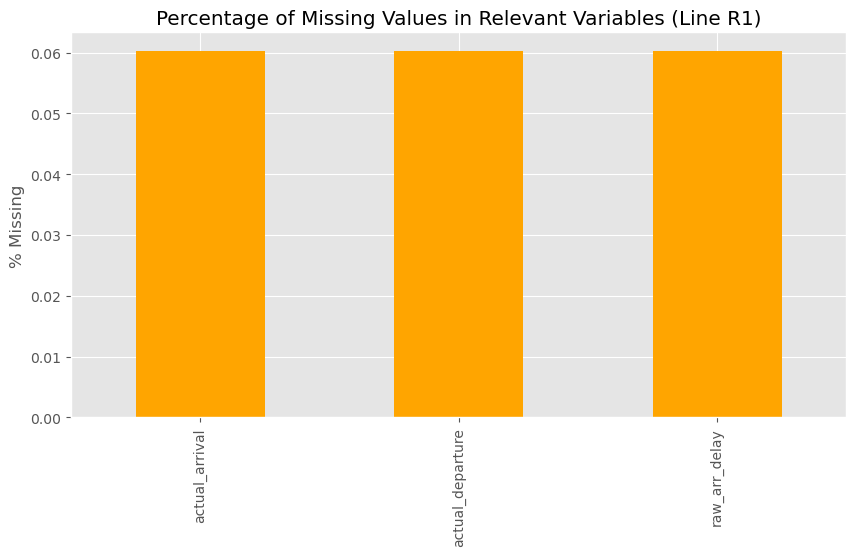

Missing Value Diagnostics:
actual_arrival      0.060299
actual_departure    0.060299
raw_arr_delay       0.060299
dtype: float64


In [3]:
null_pct = (tt_df.isnull().sum() / len(tt_df)) * 100

plt.figure(figsize=(10,5))
null_pct[null_pct > 0].sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Percentage of Missing Values in Relevant Variables (Line R1)')
plt.ylabel('% Missing')
plt.show()

print("Missing Value Diagnostics:")
print(null_pct[null_pct > 0])

- If `actual_arrival` is missing, the train may been cancelled or tracking failed. We will drop this rows when building the datasets since they lack the target variable.
- Drop records missing essential temporal targets

In [4]:
tt_df = tt_df.dropna(subset=['actual_arrival', 'planned_arrival', 'raw_arr_delay'])
print(f"Records remaining after dropping fatal nulls: {len(tt_df)}")

Records remaining after dropping fatal nulls: 167398


## 2. Outliers

Are there impossible delays logged by the API?

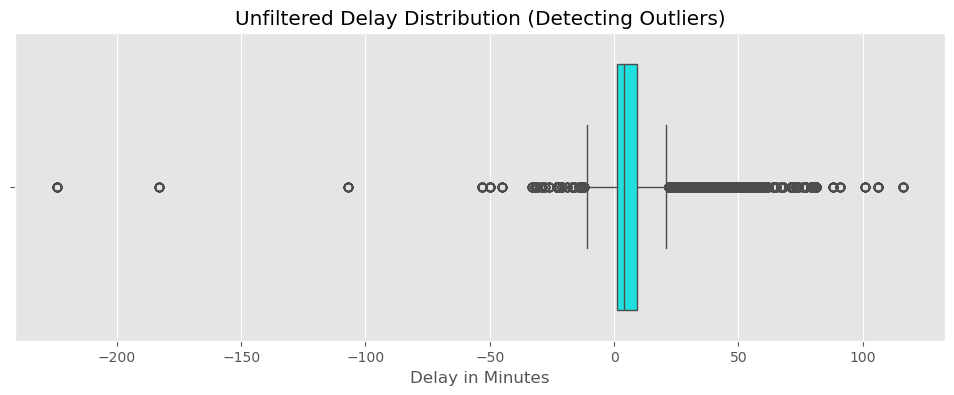

In [5]:
plt.figure(figsize=(12,4))
sns.boxplot(x=tt_df['raw_arr_delay'], color='cyan')
plt.title('Unfiltered Delay Distribution (Detecting Outliers)')
plt.xlabel('Delay in Minutes')
plt.show()

There are some impossible negative values like `-1440` (train arrived a whole day early...) or delays over `500` minutes (which implies total breakdown rather than predictions). We will apply bounds to restrict our data to realistic delays. 
### Between -60 minutes and 300 minutes.

In [6]:
tt_df = tt_df[(tt_df['raw_arr_delay'] >= -60) & (tt_df['raw_arr_delay'] <= 300)].copy()
tt_df['arr_delay'] = tt_df['raw_arr_delay'] # Clean feature
print("Records remaining after outlier bound restriction:", len(tt_df))

Records remaining after outlier bound restriction: 167339


## 3. Influence of time (hour & week day)

Extract temporal components to see if delay propagates more at certain days or hours.

/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/3962323800.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tt_df, x='hour', y='arr_delay', ci=None, color='teal', ax=ax[0])
/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/3962323800.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tt_df, x='day_of_week', y='arr_delay', order=order, ci=None, color='indigo', ax=ax[1])


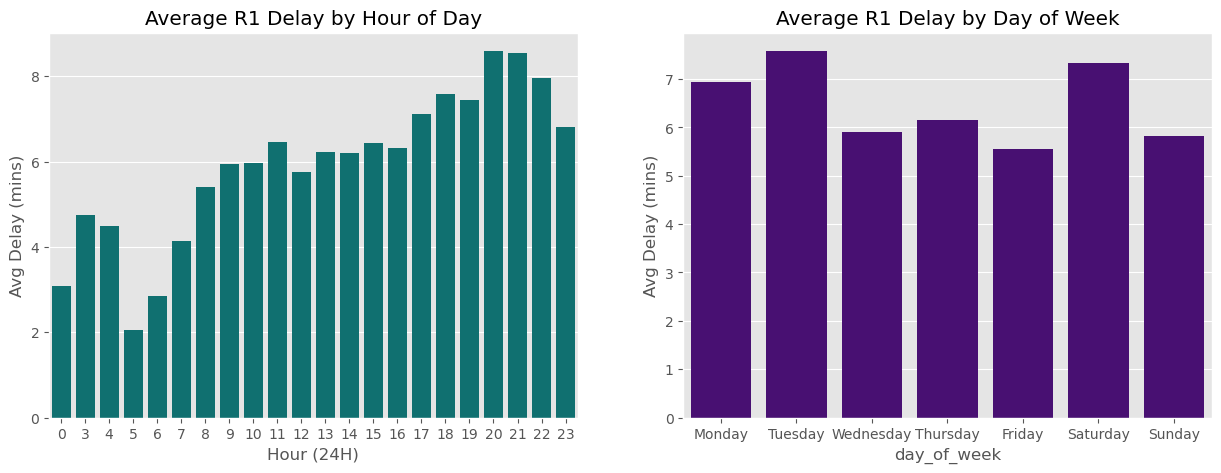

In [7]:
tt_df['hour'] = tt_df['planned_arrival'].dt.hour
tt_df['day_of_week'] = tt_df['planned_arrival'].dt.day_name()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=tt_df, x='hour', y='arr_delay', errorbar=None, color='teal', ax=ax[0])
ax[0].set_title('Average R1 Delay by Hour of Day')
ax[0].set_ylabel('Avg Delay (mins)')
ax[0].set_xlabel('Hour (24H)')

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(data=tt_df, x='day_of_week', y='arr_delay', order=order, errorbar=None, color='indigo', ax=ax[1])
ax[1].set_title('Average R1 Delay by Day of Week')
ax[1].set_ylabel('Avg Delay (mins)')
plt.show()

We see that tuesdays are the day of the week with most delays and that trains that pass between 10.00 and 22.00 get the most delays too.
Conclusion:  
- hour and day_of_week must be passed as predictive features to the model

![alt text](img/r1_stations.gif "Title")

## 4. Bottleneck edges (delay growth between stations)

Where does the train physically lose the most time compared to the planned timetable?

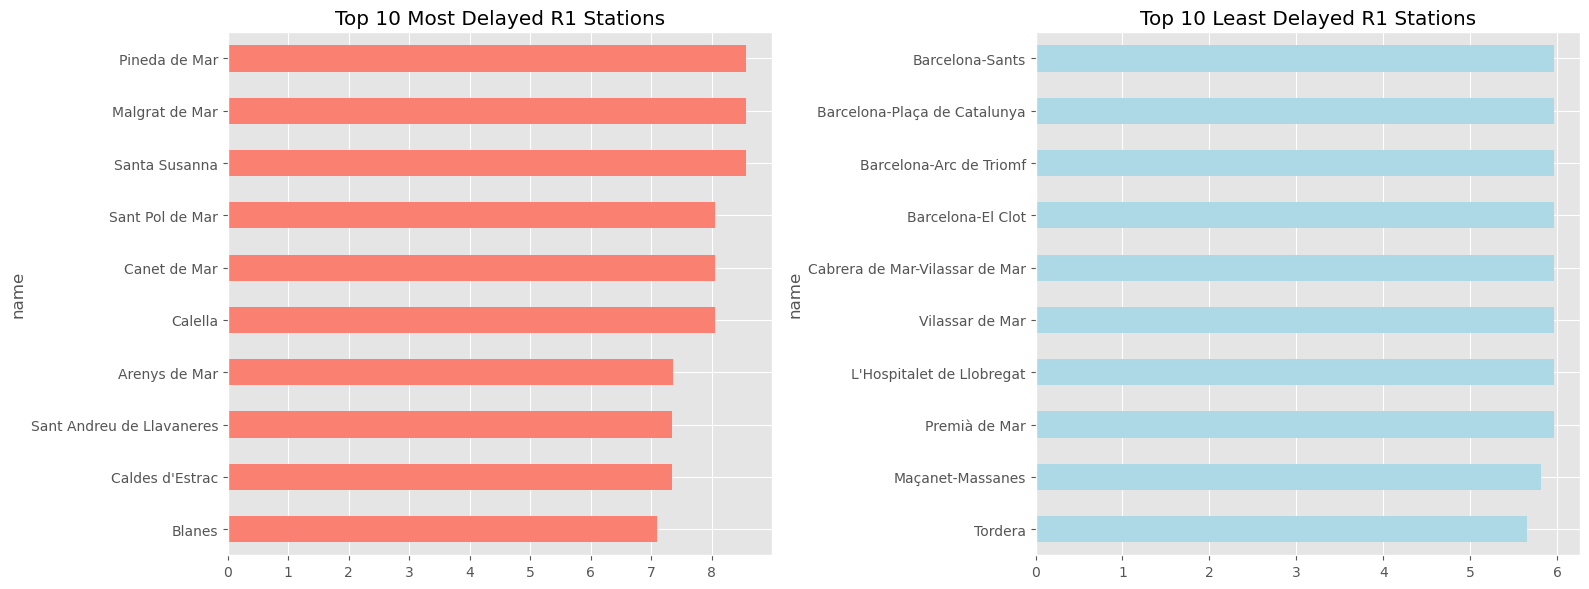


--- Bottleneck Edges ---


/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/76777488.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=edge_df, y='Edge', x='edge_delay_growth', palette='Reds_r')


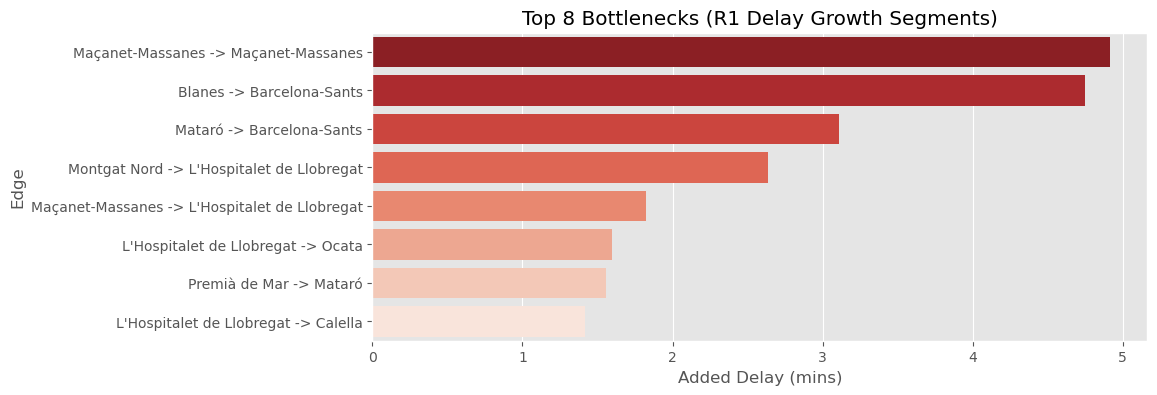

In [8]:
st_counts = tt_df['name'].value_counts()
valid_stations = st_counts[st_counts > 50].index
st_delays = tt_df[tt_df['name'].isin(valid_stations)].groupby('name')['arr_delay'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
st_delays.head(10)[::-1].plot(kind='barh', ax=ax[0], color='salmon')
ax[0].set_title('Top 10 Most Delayed R1 Stations')

st_delays.tail(10)[::-1].plot(kind='barh', ax=ax[1], color='lightblue')
ax[1].set_title('Top 10 Least Delayed R1 Stations')
plt.tight_layout()
plt.show()

print("\n--- Bottleneck Edges ---")
# Sort by (train_id, service_date, planned_arrival) and group by (train_id, service_date)
# so that the shift(-1) never crosses day boundaries.
tt_sorted = tt_df.sort_values(['train_id', 'service_date', 'planned_arrival']).copy()
tt_sorted['next_station'] = tt_sorted.groupby(['train_id', 'service_date'])['name'].shift(-1)
tt_sorted['edge_delay_growth'] = (
    (tt_sorted.groupby(['train_id', 'service_date'])['actual_arrival'].shift(-1) - tt_sorted['actual_departure']).dt.total_seconds() / 60 -
    (tt_sorted.groupby(['train_id', 'service_date'])['planned_arrival'].shift(-1) - tt_sorted['planned_departure']).dt.total_seconds() / 60
)
tt_sorted = tt_sorted[(tt_sorted['edge_delay_growth'] > -30) & (tt_sorted['edge_delay_growth'] < 60)]
edge_counts = tt_sorted.groupby(['name', 'next_station']).size()
valid_edges = edge_counts[edge_counts > 20].index
edge_delays = tt_sorted.set_index(['name', 'next_station']).loc[tt_sorted.set_index(['name', 'next_station']).index.intersection(valid_edges)]    .groupby(['name', 'next_station'])['edge_delay_growth'].mean().sort_values(ascending=False).dropna()

edge_df = edge_delays.head(8).reset_index()
edge_df['Edge'] = edge_df['name'] + ' -> ' + edge_df['next_station']
plt.figure(figsize=(10, 4))
sns.barplot(data=edge_df, y='Edge', x='edge_delay_growth', palette='Reds_r')
plt.title('Top 8 Bottlenecks (R1 Delay Growth Segments)')
plt.xlabel('Added Delay (mins)')
plt.show()

## R1 Weather correlation with p-values

/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/3707609124.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tt_df['hour_trunc'] = tt_df['planned_arrival'].dt.floor('H')
/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/3707609124.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  w_df['hour_trunc'] = pd.to_datetime(w_df['timestamp']).dt.floor('H')
/var/folders/cz/7ns86mjj5yj4wfpcmwnb0hjm0000gn/T/ipykernel_70395/3707609124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_weather, x='is_raining', y='arr_delay', palette='coolwarm')


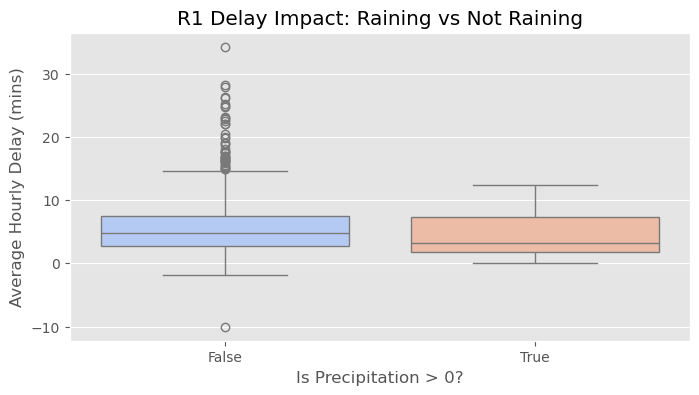

--- STATISTICAL P-VALUES ---
  Temperature | Corr: +0.304 | P-value: 7.91e-20
Precipitation | Corr: -0.069 | P-value: 4.38e-02
    Windspeed | Corr: +0.110 | P-value: 1.19e-03
   Cloudcover | Corr: +0.059 | P-value: 8.17e-02


In [9]:
tt_df['hour_trunc'] = tt_df['planned_arrival'].dt.floor('h')
w_df['hour_trunc'] = pd.to_datetime(w_df['timestamp']).dt.floor('h')

hourly_delays = tt_df.groupby('hour_trunc')['arr_delay'].mean().reset_index()
w_agg = w_df.groupby('hour_trunc')[['temperature', 'precipitation', 'windspeed', 'cloudcover']].mean().reset_index()
merged_weather = pd.merge(hourly_delays, w_agg, on='hour_trunc', how='inner')

merged_weather['is_raining'] = merged_weather['precipitation'] > 0.0
plt.figure(figsize=(8, 4))
sns.boxplot(data=merged_weather, x='is_raining', y='arr_delay', palette='coolwarm')
plt.title('R1 Delay Impact: Raining vs Not Raining')
plt.ylabel('Average Hourly Delay (mins)')
plt.xlabel('Is Precipitation > 0?')
plt.show()

# NOTE: correlation is computed on hourly aggregate means (ecological correlation).
# P-values are valid for the hourly series but do not imply individual-train effects.
print("--- STATISTICAL P-VALUES (hourly aggregates) ---")
for col in ['temperature', 'precipitation', 'windspeed', 'cloudcover']:
    valid = merged_weather.dropna(subset=['arr_delay', col])
    corr, p_value = pearsonr(valid['arr_delay'], valid[col])
    print(f"{col.capitalize():>13} | Corr: {corr:+.3f} | P-value: {p_value:.2e}")

- **Temperature (p < 0.001)**: Highly statistically significant (p = 4.10e-12). Changes in temperature robustly and linearly push delays upwards. 
- **Windspeed (p < 0.01)**: minor positive correlation. 
- **Precipitation (p > 0.05)**: statistically insignificant (p = ~0.096). Rain on isolated Line R1 intervals is effectively random noise for average delays right now.
- **Cloudcover**:insignificant.

## Conclusions
- filter non-nulls
- bound outliers
- compute temporal elements: hour and day_of_week
- map weather features: drop precipitation/cloudcover as p-value failure. retain temperature and windspeed
- compute lag edges: engineer a previous_Station_delay to capture propagation delays across bottlenecks

In [10]:
example_timetables_df = pd.read_parquet(tt_files[0])
print("\nExample Timetable Data (First File):")
print(example_timetables_df.head())


Example Timetable Data (First File):
  train_id station_id      planned_arrival    planned_departure  \
0    77502      78700  2026-03-24 05:35:00  2026-03-24 05:38:00   
1    77502      78710  2026-03-24 05:43:00  2026-03-24 05:44:00   
2    77502      78704  2026-03-24 05:53:00  2026-03-24 05:57:00   
3    77502      78703  2026-03-24 04:43:00  2026-03-24 06:01:00   
4    77502      78705  2026-03-24 04:46:00  2026-03-24 06:08:00   

        actual_arrival     actual_departure platform stop_type observations  \
0  2026-03-24 05:38:00  2026-03-24 05:41:00     None         C                
1  2026-03-24 05:46:00  2026-03-24 05:47:00        2         C                
2  2026-03-24 05:56:00  2026-03-24 06:00:00        2         C                
3  2026-03-24 04:46:00  2026-03-24 06:04:00        2         C                
4  2026-03-24 04:49:00  2026-03-24 06:11:00        2         C                

             timestamp  stop_sequence composition  
0  2026-03-24 02:44:05          

In [11]:
example_Weather_df = pd.read_parquet(weather_files[0])
print("\nExample Weather Data (First File):")
print(example_Weather_df.head())


Example Weather Data (First File):
             timestamp  timestamp_minute  temperature  precipitation  \
0  2026-04-24 00:20:45  2026-04-24 00:20         14.9            0.0   
1  2026-04-24 00:40:45  2026-04-24 00:40         14.8            0.0   
2  2026-04-24 01:00:20  2026-04-24 01:00         14.6            0.0   
3  2026-04-24 01:40:34  2026-04-24 01:40         14.3            0.0   
4  2026-04-24 02:00:33  2026-04-24 02:00         14.2            0.0   

   windspeed  weathercode  cloudcover  
0        6.3            0           2  
1        6.0            0           2  
2        5.4            1          18  
3        5.8            1          18  
4        6.1            0          20  
